## 带趋势显示的散点图，可同时展示数据集分布状况和变化趋势。其中，数据点坐标展示分布状况，趋势线展示变化趋势。
	
## 趋势线通常是数据集经过线性、多项式或其它拟合方式得到的。在本示例中，三组数据趋势线分别使用线性、二次多项式和指数曲线拟合得到。


In [4]:
"""使用 matplotlib 绘制带趋势显示的散点图"""
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

In [5]:

def load_style():
    """加载样式文件（如果存在），并设置中文字体支持"""
    # 设置样式
    try:
        plt.style.use("scatter.mplstyle")
    except:
        pass
    # 使用Nature常用的无衬线字体，Ubuntu系统兼容
    plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "Helvetica", "sans-serif"]
    plt.rcParams["axes.unicode_minus"] = False

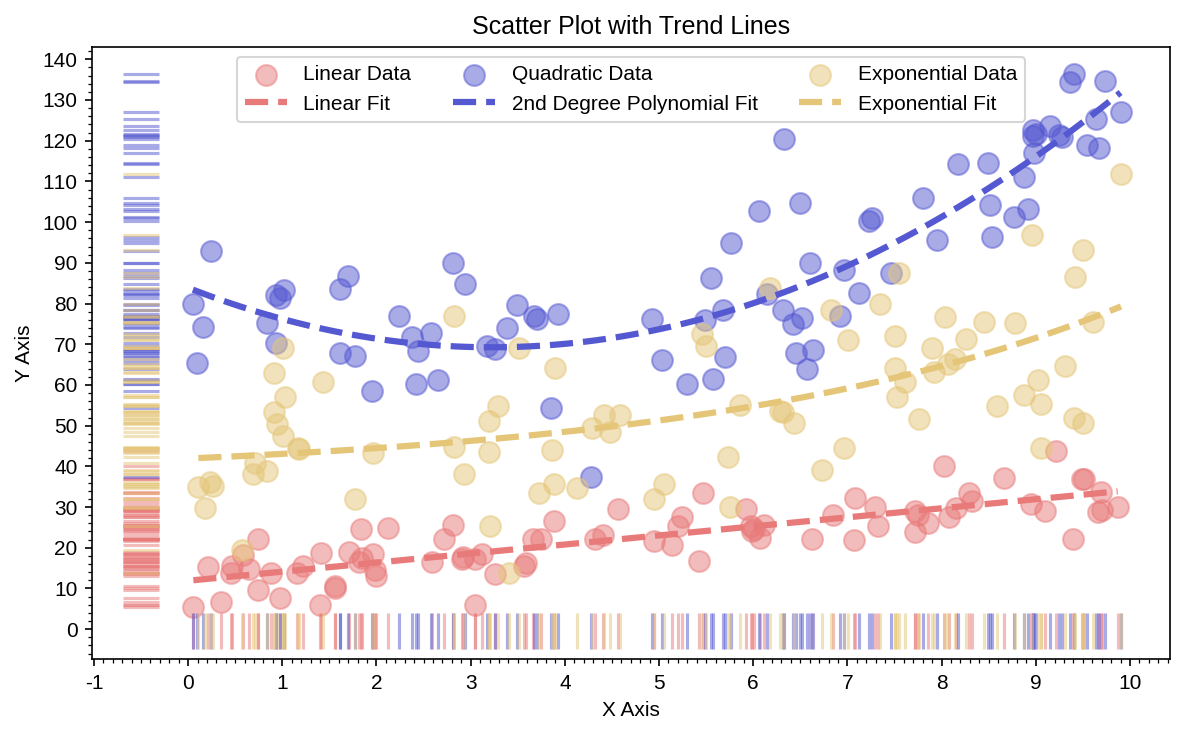

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.ticker as ticker

def linear_fit(X, Y, color, ax):
    """Linear fit (1st degree polynomial)"""
    coefficients = np.polyfit(X, Y, 1)
    polynomial = np.poly1d(coefficients)
    xs = np.linspace(np.min(X), np.max(X), 100)
    ys = polynomial(xs)
    ax.plot(
        xs, ys, 
        color=color, 
        linestyle="--", 
        linewidth=3, 
        label="Linear Fit"
    )

def polynomial_fit(X, Y, color, ax):
    """Quadratic polynomial fit (2nd degree polynomial)"""
    coefficients = np.polyfit(X, Y, 2)
    polynomial = np.poly1d(coefficients)
    xs = np.linspace(np.min(X), np.max(X), 100)
    ys = polynomial(xs)
    ax.plot(
        xs, ys, 
        color=color, 
        linestyle="--", 
        linewidth=3, 
        label="2nd Degree Polynomial Fit"
    )

def exponential_fit(X, Y, color, ax):
    """Exponential fit"""
    def model(x, a, b, c):
        return a * np.exp(b * x) + c
    
    popt, _ = curve_fit(model, X, Y)
    xs = np.linspace(np.min(X), np.max(X), 100)
    ys = model(xs, *popt)
    ax.plot(
        xs, ys, 
        color=color, 
        linestyle="--", 
        linewidth=3, 
        label="Exponential Fit"
    )

def create_chart(ax):
    """Create scatter plot with trend lines (linear, quadratic, exponential)"""
    n = 80
    np.random.seed(42)  # Fix random seed for reproducibility

    # Generate simulated data
    # Linear data
    X1 = np.random.uniform(0, 10, n)
    Y1 = 2 * X1 + 3 + np.random.normal(0, 5, n) + 10
    # Quadratic polynomial data
    X2 = np.random.uniform(0, 10, n)
    Y2 = 1.5 * X2**2 - 10 * X2 + 5 + np.random.normal(0, 10, n) + 80
    # Exponential data
    X3 = np.random.uniform(0, 10, n)
    Y3 = 2 * np.exp(0.3 * X3) + np.random.normal(0, 15, n) + 40

    # Mapping of data, colors, labels, and fitting functions
    colors = ["#e97a7a", "#5559d1", "#e5c679"]
    Xs = [X1, X2, X3]
    Ys = [Y1, Y2, Y3]
    labels = ["Linear Data", "Quadratic Data", "Exponential Data"]
    functions = [linear_fit, polynomial_fit, exponential_fit]

    # Plot scatter points + fitting curves + projection markers
    for i in range(3):
        # Main scatter points
        ax.scatter(
            Xs[i], Ys[i], 
            s=100, 
            c=colors[i], 
            alpha=0.5, 
            label=labels[i]
        )
        # Horizontal axis projections (at y=-0.5, vertical line markers)
        ax.scatter(
            Xs[i], [-0.5] * len(Xs[i]), 
            marker="|", 
            color=colors[i], 
            alpha=0.5, 
            s=300
        )
        # Vertical axis projections (at x=-0.5, horizontal line markers)
        ax.scatter(
            [-0.5] * len(Xs[i]), Ys[i], 
            marker="_", 
            color=colors[i], 
            alpha=0.5, 
            s=300
        )
        # Fitting curves
        functions[i](Xs[i], Ys[i], colors[i], ax)

    # Set axis ticks
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))    # X-axis major tick interval 1
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))  # X-axis minor tick interval 0.1
    ax.yaxis.set_major_locator(ticker.MultipleLocator(10))   # Y-axis major tick interval 10
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))    # Y-axis minor tick interval 2

    # Set title and labels
    ax.set_title("Scatter Plot with Trend Lines")
    ax.set_xlabel("X Axis")
    ax.set_ylabel("Y Axis")

    # Set legend (centered, 3 columns)
    ax.legend(ncols=3, loc="upper center")

    # Optimize layout
    plt.tight_layout()

if __name__ == "__main__":
    # Assuming load_style() is defined elsewhere
    # load_style()
    # Create figure (8x5 inches, 150 DPI)
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    create_chart(ax)
    plt.show()